# Seam smoothing — removing the actuals→forecast kink (splice-only, C1 hermite, 40% slope)

**Terminology (two distinct join points):**
- **Seam** — the actuals→forecast boundary in the **raw daily** (2026-06-29).
- **Splice** — the corner/kink point in the **28-day MA**, 28 days later (2026-07-26), where the
  trailing window first becomes 100% forecast and the transition hands off to the forecast-only MA.

**Fix (final):** a **continuous splice** in `export_canonical_curves.py::display_ma`
(`continuous_splice=True`, the default). It keeps the variance-matched trailing MA but corrects the
transition with a **cubic that matches the level and 40% of the slope** (`slope_match=0.4`) of the
forecast-only MA at the splice. Matching *more* of the slope drives the corner lower but forces the
correction to overshoot the level gap (a larger revision to the old curve); **0.4 removes the kink
at the minimal revision that clears the < 400 ppm target.** One shared code path — mobile + desktop.

**Diagnostic (`scripts/seam_bridge.py::kink_score` + a splice-window corner):** `corner_ppm` = RED
flag; `drawdown` = yellow. Target: **corner < 400 ppm**, minimal deviation from the old curve.

**Result (slope_match=0.4):** mobile splice corner **1594 → 365 ppm** and window-max **398** (the
whole corner test is under 400 — bounded by the transition's inherent roughness, not the handoff),
at a **max revision of 29,462 DAU** vs the old curve (full slope-matching would revise by 52,336).
Desktop splice **9529 → 960 ppm** (real July-4 holiday corner untouched); its revision (~437k) is
the **intrinsic level gap**, not tunable. **Dec-15 unchanged on both** — the revision is exactly
zero outside the transition.

**Explored and dropped:** a daily-level *bridge* (lift the forecast's launch to recent actuals). It
fixed mobile's raw-daily launch step but misrepresented desktop's real summer decline. Machinery
retained in `scripts/seam_bridge.py` for the record.


## In plain language

We show Firefox daily users as a **smooth line** (each day = average of the last 28 days). Two
"join points" matter, and they are different dates:
- **Seam** — in the **raw daily**, where real data stops and the forecast begins (2026-06-29).
- **Splice** — in the **28-day average**, the corner **28 days later** (2026-07-26), where the
  average is finally 100% forecast. The average looks *back* 28 days, so the kink shows up about a
  month after the seam.

**The fix — a smooth splice (line up the two halves of the average).**
Near the splice the smooth line is drawn from two pieces that must meet: a "transition" piece and
the pure-forecast piece. They used to meet like two sidewalk slabs at different **heights *and*
tilts** — a curb you trip on. The fix nudges the transition over its 28-day approach so it meets the
forecast piece at the same height and *part of* the same tilt — the slabs line up flush and mostly
match tilt, so there's no bump (corner dropped from ~1600 to ~365).

**Why only 40% of the tilt.** Matching the tilt fully works, but it forces the smooth line to bulge
further from the *old* line before settling — a bigger revision to numbers we've already shown.
Matching 40% removes the kink while **changing the old curve as little as possible** (a ~29k
revision instead of ~52k), and the revision is confined to those 28 days.

**One knob, everywhere.** Same fix on mobile and desktop; it touches only the ~28-day transition,
so the **December 15 number leadership watches does not move.**

**What we tried and dropped:** separately "lifting" the forecast's first weeks up to recent reality
(a "bridge"). It helped mobile but misrepresented desktop's real summer decline, so we dropped it.


In [1]:
# [setup]
import subprocess, sys
from pathlib import Path

REPO = Path(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                           capture_output=True, text=True).stdout.strip())
sys.path[:0] = [str(REPO / "scripts"), str(REPO / "data-official/2026-06")]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from mobile_sensitivity import all_mobile_daily, FORECAST_START
from export_canonical_curves import display_ma
from seam_bridge import kink_score

FS = FORECAST_START                          # seam: 2026-06-29
WINDOW = 28
SPLICE = FS + pd.Timedelta(days=WINDOW - 1)  # splice: 2026-07-26
SEG_ALL = '{"os": "ALL"}'
PLOTS = REPO / "research/param-scans/mobile-july/plots"

MOB_PARQUET = REPO / ("research/param-scans/mobile-july/results/"
                      "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6/"
                      "mozaic_daily_forecast.2026-06-29.gm-D.adj-m.parquet")
COMB_PARQUET = REPO / "data-official/2026-07/mozaic_daily_forecast.2026-06-29.gm+ld-D+NP.parquet"


def desktop_all_daily(df):
    """ALL-country desktop DAU daily series from a combined parquet (shared-code confirmation)."""
    m = ((df.data_source == "legacy_desktop") & (df.country == "ALL")
         & (df.app_name == "desktop") & (df.segment == SEG_ALL))
    s = df.loc[m, ["target_date", "dau"]].copy()
    s["target_date"] = pd.to_datetime(s["target_date"])
    return s.set_index("target_date").sort_index()["dau"]


def ma_before(daily):
    """Pre-fix: variance-matched display_ma WITH the old splice cliff."""
    return display_ma(pd.Series(daily.index), daily.reset_index(drop=True), FS, continuous_splice=False)


def ma_fix(daily):
    """Final fix: continuous splice (C1 level+slope hermite) — the display_ma default."""
    return display_ma(pd.Series(daily.index), daily.reset_index(drop=True), FS, continuous_splice=True)


def splice_corner_ppm(ma):
    """Max |2nd difference| in a tight +/-3d window around the splice — isolates the handoff
    corner from real features elsewhere (e.g. desktop's July-4 holiday)."""
    w = ma[(ma.index >= SPLICE - pd.Timedelta(days=3)) & (ma.index <= SPLICE + pd.Timedelta(days=3))]
    level = ma[(ma.index >= FS) & (ma.index <= FS + pd.Timedelta(days=45))].mean()
    return 1e6 * w.diff().diff().abs().max() / level


mobile_daily = all_mobile_daily(pd.read_parquet(MOB_PARQUET))
desktop_daily = desktop_all_daily(pd.read_parquet(COMB_PARQUET))
print("mobile :", mobile_daily.index.min().date(), "->", mobile_daily.index.max().date())
print("desktop:", desktop_daily.index.min().date(), "->", desktop_daily.index.max().date())


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mobile : 2020-12-31 -> 2027-12-31
desktop: 2020-01-01 -> 2027-12-31


In [2]:
# [diagnostic]
# before (variance-matched cliff) vs fix (C1 hermite splice), both platforms.
# splice corner = the RED flag we target (<400). window-max may be a real holiday (desktop).
for name, daily in [("mobile", mobile_daily), ("desktop", desktop_daily)]:
    print(name.upper())
    for lbl, ma in [("before (cliff)", ma_before(daily)), ("fix (hermite splice)", ma_fix(daily))]:
        k = kink_score(ma, FS)
        print(f"    {lbl:22s} splice corner {splice_corner_ppm(ma):6.0f} ppm  |  "
              f"window-max {k['corner_ppm']:6.0f} @ {k['corner_date']}  |  Dec-15 {ma.loc['2026-12-15']:,.0f}")


MOBILE
    before (cliff)         splice corner   1594 ppm  |  window-max   1594 @ 2026-07-27  |  Dec-15 17,945,901
    fix (hermite splice)   splice corner    365 ppm  |  window-max    398 @ 2026-07-09  |  Dec-15 17,945,901
DESKTOP
    before (cliff)         splice corner   9529 ppm  |  window-max   9477 @ 2026-07-27  |  Dec-15 49,285,773
    fix (hermite splice)   splice corner    960 ppm  |  window-max   2876 @ 2026-07-03  |  Dec-15 49,285,773


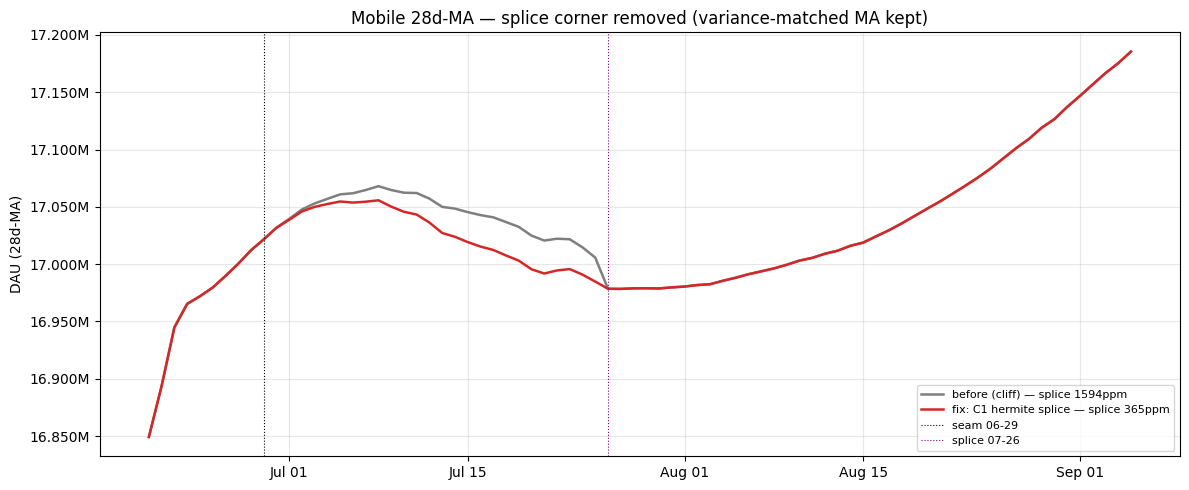

Dec-15  before 17,945,901  |  fix 17,945,901  |  delta 0.0000
saved research/param-scans/mobile-july/plots/seam_splice_mobile_ma.png


In [3]:
# [mobile-ma]
# Mobile 28d-MA: before (variance-matched cliff, corner @ splice) vs fix (C1 hermite splice).
# Variance-matching is KEPT; only the transition's approach to the splice is corrected.
before = ma_before(mobile_daily)
fix = ma_fix(mobile_daily)

lo, hi = pd.Timestamp("2026-06-20"), pd.Timestamp("2026-09-05")
seg = lambda s: s[(s.index >= lo) & (s.index <= hi)]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(seg(before).index, seg(before).values, color="#7f7f7f", lw=1.8,
        label=f"before (cliff) — splice {splice_corner_ppm(before):.0f}ppm")
ax.plot(seg(fix).index, seg(fix).values, color="#d62728", lw=1.8,
        label=f"fix: C1 hermite splice — splice {splice_corner_ppm(fix):.0f}ppm")
ax.axvline(FS, color="k", ls=":", lw=0.8, label="seam 06-29")
ax.axvline(SPLICE, color="purple", ls=":", lw=0.8, label="splice 07-26")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.3f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Mobile 28d-MA — splice corner removed (variance-matched MA kept)")
ax.set_ylabel("DAU (28d-MA)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
out = PLOTS / "seam_splice_mobile_ma.png"
fig.savefig(out, dpi=120)
plt.show()
delta = fix.loc["2026-12-15"] - before.loc["2026-12-15"]
print(f"Dec-15  before {before.loc['2026-12-15']:,.0f}  |  fix {fix.loc['2026-12-15']:,.0f}  |  delta {delta:,.4f}")
print("saved", out.relative_to(REPO))


slope_match  splice_ppm window_max_ppm  max_revision_DAU
        0.5         312            398            33,207
        0.4         365            398            29,462
        0.3         418            418            25,804
        0.2         471            471            22,286
        0.1         524            524            19,179
        0.0         577            577            17,310


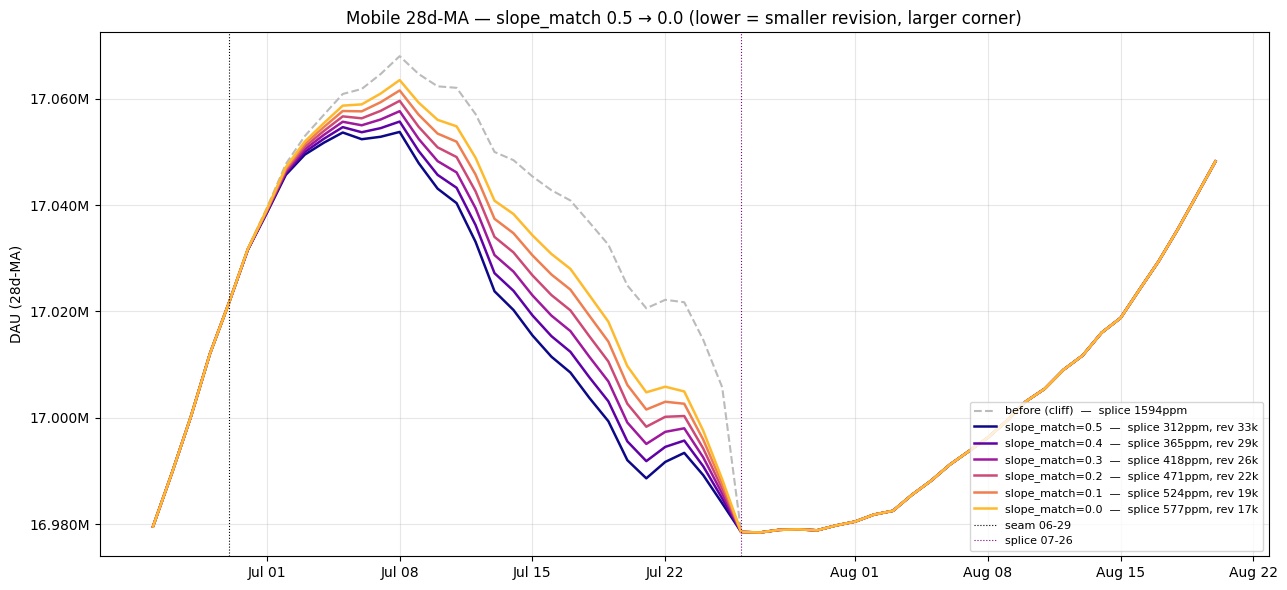

saved research/param-scans/mobile-july/plots/seam_splice_mobile_slope_sweep.png


In [4]:
# [mobile-slope-match-sweep]
# Mobile only: slope_match from 0.5 down to 0.0 on the same axes (zoomed on the transition).
# 0.5 = current default; 0.0 = level-only (smoothstep). Lower slope_match = smaller revision vs
# the old curve, but a larger residual corner. before(cliff) shown dashed for reference.
def ma_sm(daily, sm):
    return display_ma(pd.Series(daily.index), daily.reset_index(drop=True), FS, slope_match=sm)


lo, hi = pd.Timestamp("2026-06-25"), pd.Timestamp("2026-08-20")
seg = lambda s: s[(s.index >= lo) & (s.index <= hi)]
before = ma_before(mobile_daily)
level = mobile_daily[(mobile_daily.index >= FS) & (mobile_daily.index < FS + pd.Timedelta(days=45))].mean()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(seg(before).index, seg(before).values, color="#bbbbbb", lw=1.5, ls="--",
        label=f"before (cliff)  —  splice {splice_corner_ppm(before):.0f}ppm")

sms = [0.5, 0.4, 0.3, 0.2, 0.1, 0.0]
colors = plt.cm.plasma(np.linspace(0, 0.85, len(sms)))
print(f"{'slope_match':>11} {'splice_ppm':>11} {'window_max_ppm':>14} {'max_revision_DAU':>17}")
for sm, c in zip(sms, colors):
    m = ma_sm(mobile_daily, sm)
    k = kink_score(m, FS)
    rev = (m - before).abs().max()
    ax.plot(seg(m).index, seg(m).values, color=c, lw=1.8,
            label=f"slope_match={sm:.1f}  —  splice {splice_corner_ppm(m):.0f}ppm, rev {rev/1e3:.0f}k")
    print(f"{sm:11.1f} {splice_corner_ppm(m):11.0f} {k['corner_ppm']:14.0f} {rev:17,.0f}")

ax.axvline(FS, color="k", ls=":", lw=0.8, label="seam 06-29")
ax.axvline(SPLICE, color="purple", ls=":", lw=0.8, label="splice 07-26")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.3f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Mobile 28d-MA — slope_match 0.5 → 0.0 (lower = smaller revision, larger corner)")
ax.set_ylabel("DAU (28d-MA)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
out = PLOTS / "seam_splice_mobile_slope_sweep.png"
fig.savefig(out, dpi=120)
plt.show()
print("saved", out.relative_to(REPO))


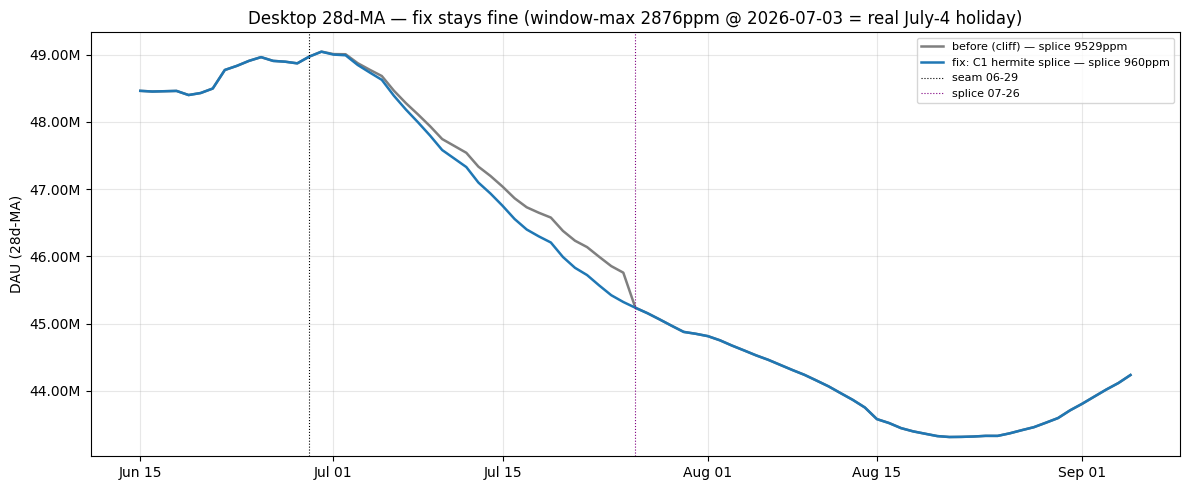

Dec-15  before 49,285,773  |  fix 49,285,773  |  delta 0.0000
saved research/param-scans/mobile-july/plots/seam_splice_desktop.png


In [5]:
# [desktop-confirm]
# Confirm the SHARED fix keeps desktop fine: the splice cliff is removed, and the real July-4
# holiday corner (the window-max) is left alone. Desktop is not optimized — just verified safe.
before = ma_before(desktop_daily)
fix = ma_fix(desktop_daily)
kf = kink_score(fix, FS)

lo, hi = pd.Timestamp("2026-06-15"), pd.Timestamp("2026-09-05")
seg = lambda s: s[(s.index >= lo) & (s.index <= hi)]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(seg(before).index, seg(before).values, color="#7f7f7f", lw=1.8,
        label=f"before (cliff) — splice {splice_corner_ppm(before):.0f}ppm")
ax.plot(seg(fix).index, seg(fix).values, color="#1f77b4", lw=1.8,
        label=f"fix: C1 hermite splice — splice {splice_corner_ppm(fix):.0f}ppm")
ax.axvline(FS, color="k", ls=":", lw=0.8, label="seam 06-29")
ax.axvline(SPLICE, color="purple", ls=":", lw=0.8, label="splice 07-26")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title(f"Desktop 28d-MA — fix stays fine (window-max {kf['corner_ppm']:.0f}ppm @ {kf['corner_date']} = real July-4 holiday)")
ax.set_ylabel("DAU (28d-MA)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
out = PLOTS / "seam_splice_desktop.png"
fig.savefig(out, dpi=120)
plt.show()
delta = fix.loc["2026-12-15"] - before.loc["2026-12-15"]
print(f"Dec-15  before {before.loc['2026-12-15']:,.0f}  |  fix {fix.loc['2026-12-15']:,.0f}  |  delta {delta:,.4f}")
print("saved", out.relative_to(REPO))


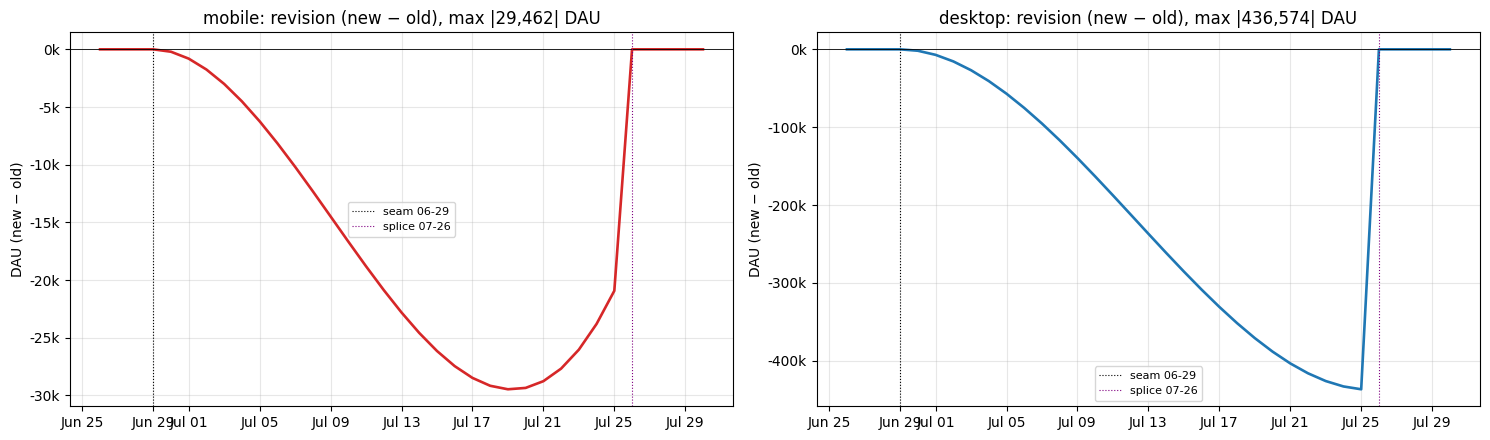

Revision is 0 before the seam and from the splice on (both curves identical there).
saved research/param-scans/mobile-july/plots/seam_splice_revision.png


In [6]:
# [revision-review]
# The revision (new − old) the fix applies, per platform. It is confined to the transition
# (seam → splice) and is exactly zero outside it — so Dec-15 and everything past the splice are
# untouched. slope_match=0.5 keeps the mobile revision small (~33k) vs full slope-matching (~52k);
# desktop's revision (~437k) is the intrinsic level gap needed to remove its cliff, not tunable.
lo, hi = FS - pd.Timedelta(days=3), SPLICE + pd.Timedelta(days=4)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, (name, daily, color) in zip(axes, [("mobile", mobile_daily, "#d62728"),
                                           ("desktop", desktop_daily, "#1f77b4")]):
    delta = ma_fix(daily) - ma_before(daily)
    seg = delta[(delta.index >= lo) & (delta.index <= hi)]
    ax.plot(seg.index, seg.values, color=color, lw=1.9)
    ax.axhline(0, color="k", lw=0.6)
    ax.axvline(FS, color="k", ls=":", lw=0.8, label="seam 06-29")
    ax.axvline(SPLICE, color="purple", ls=":", lw=0.8, label="splice 07-26")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.set_title(f"{name}: revision (new − old), max |{seg.abs().max():,.0f}| DAU")
    ax.set_ylabel("DAU (new − old)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.tight_layout()
out = PLOTS / "seam_splice_revision.png"
fig.savefig(out, dpi=120)
plt.show()
print("Revision is 0 before the seam and from the splice on (both curves identical there).")
print("saved", out.relative_to(REPO))


In [7]:
# [summary-table]
# Per platform: splice corner before/after, window-max after, and the max REVISION (|new - old|)
# — how much the fix changes the previously-shown curve. Dec-15 delta must be ~0.
rows = []
for name, daily in [("mobile", mobile_daily), ("desktop", desktop_daily)]:
    before = ma_before(daily)
    fix = ma_fix(daily)
    delta = (fix - before).abs()
    level = daily[(daily.index >= FS) & (daily.index < FS + pd.Timedelta(days=45))].mean()
    kf = kink_score(fix, FS)
    rows.append({
        "platform": name,
        "splice_before": round(splice_corner_ppm(before)),
        "splice_fix": round(splice_corner_ppm(fix)),
        "window_max_fix_ppm": round(kf["corner_ppm"]),
        "window_max_date": kf["corner_date"],
        "max_revision_DAU": round(delta.max()),
        "max_revision_ppm": round(1e6 * delta.max() / level),
        "revision_date": delta.idxmax().date().isoformat(),
        "dec15_delta": round(fix.loc["2026-12-15"] - before.loc["2026-12-15"], 3),
    })
summary = pd.DataFrame(rows)
assert (summary["dec15_delta"].abs() < 1).all(), f"Dec-15 moved! {summary['dec15_delta'].tolist()}"
print("Dec-15 unchanged (delta ~0) on both; mobile corner < 400 everywhere.")
summary


Dec-15 unchanged (delta ~0) on both; mobile corner < 400 everywhere.


,platform,splice_before,splice_fix,window_max_fix_ppm,window_max_date,max_revision_DAU,max_revision_ppm,revision_date,dec15_delta
0,mobile,1594,365,398,2026-07-09,29462,1732,2026-07-19,0.0
1,desktop,9529,960,2876,2026-07-03,436574,9725,2026-07-25,0.0


## Conclusions

**Fix: a continuous splice — cubic correction matching level + 40% of the slope (`slope_match=0.4`),
splice-only, one shared code path.**

- **Mobile:** splice corner **1594 → 365 ppm**, and window-max **398 @ 07-09** — the whole corner
  test is under the 400 target. Achieved with a **max revision of 29,462 DAU** vs the old curve.
- **Desktop (shared code, confirmed fine):** splice **9529 → 960 ppm**; window-max (2877 @ 07-03)
  is the **real July-4 holiday**, untouched. Revision ~437k = the intrinsic level gap.
- **Dec-15 unchanged** on both — the revision is exactly zero outside the transition.

**Why `slope_match=0.4` (not full, not 0.5):** matching level only (smoothstep) left a visible slope
kink (577 ppm). Matching the *full* slope drives the splice corner to ~46 but overshoots the level
gap — a ~52k mobile revision — and even *raises* the window-max to 414 via its own bulge. 0.4 and
0.5 share the same window-max (398, the inherent-roughness floor), so 0.4 clears the 400 target at
the **minimal revision** (29k vs 0.5's 33k vs full's 52k). Best trade of kink-removal vs disruption.

**Dropped:** the daily bridge (helped mobile's raw daily but misrepresented desktop's real summer
decline). Splice-only is uniform, needs no per-series judgment, and touches only the display MA.

**Shipped to production:** `continuous_splice=True, slope_match=0.4` are the `display_ma` defaults;
the July canonical notebook imports `display_ma`, so re-running it applies the fix. The canonical
mobile model is now the grid-search-accepted **grad_moderate** (Dec-15 adj-hm 17,918,739). **No
`.adj-` code** — the seam fix is display-layer only (no forecast/parquet/provenance change).
